In [1]:
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Chetish\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Chetish\AppData\Roaming\nltk_data...


True

In [5]:
df = pd.read_csv("../data/labeled_tweets.csv")

print("Dataset Loaded ✅")
print(df.shape)

df.head()

Dataset Loaded ✅
(98, 2)


,tweets,sentiment
0,The only reason the iPhone stands out is its s...,neutral
1,"Its all a matter of choice, there are things ...",neutral
2,doing iPhone vs Android sigh,neutral
3,We should now introduce app multitasking on ou...,positive
4,Android gives way more flexibility and options.,positive


In [7]:
#Checking class distribution
df['sentiment'].value_counts()

sentiment
positive    39
negative    32
neutral     27
Name: count, dtype: int64

## VISUALIZATION: SENTIMENT COUNT

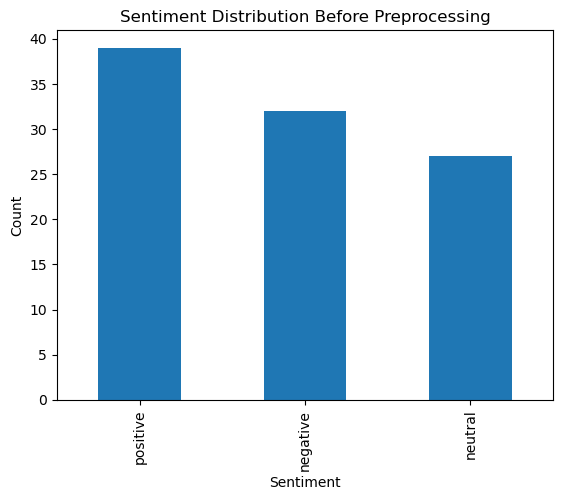

In [10]:
df['sentiment'].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution Before Preprocessing")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.savefig("../visuals/03_sentiment_before_preprocessing.png")

plt.show()

In [12]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [14]:
# TEXT CLEANING FUNCTION
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)          # remove mentions
    text = re.sub(r"#", "", text)             # remove hashtags
    text = re.sub(r"\d+", "", text)           # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    
    return " ".join(words)

In [18]:
df['clean_text'] = df['tweets'].apply(clean_text)

df[['tweets', 'clean_text']].head()

,tweets,clean_text
0,The only reason the iPhone stands out is its s...,reason iphone stand security rare find applica...
1,"Its all a matter of choice, there are things ...",its matter choice thing iphone android good b...
2,doing iPhone vs Android sigh,iphone v android sigh
3,We should now introduce app multitasking on ou...,introduce app multitasking iphone series like ...
4,Android gives way more flexibility and options.,android give way flexibility option


In [22]:
# TEXT LENGTH COMPARISON
df['original_length'] = df['tweets'].apply(len)
df['clean_length'] = df['clean_text'].apply(len)

In [24]:
## VISUALIZATION: BEFORE VS AFTER LENGTH

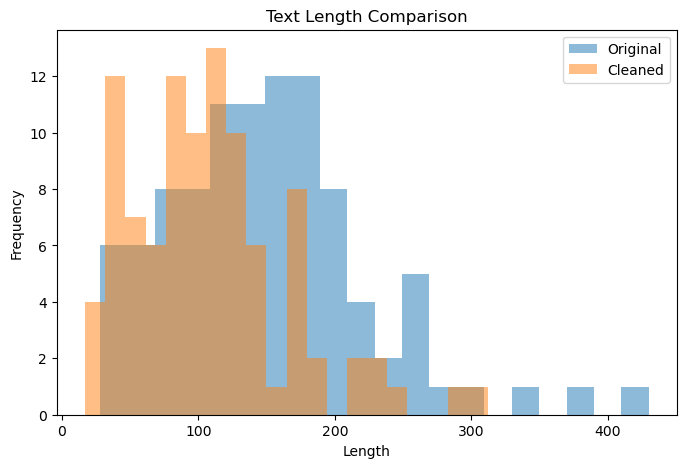

In [28]:
plt.figure(figsize=(8,5))
plt.hist(df['original_length'], bins=20, alpha=0.5, label='Original')
plt.hist(df['clean_length'], bins=20, alpha=0.5, label='Cleaned')

plt.legend()
plt.title("Text Length Comparison")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.savefig("../visuals/04_text_length_comparison.png")

plt.show()

In [30]:
X = df['clean_text']
y = df['sentiment']

## TRAIN-TEST SPLIT (80/20)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT for balanced classes
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 78
Test size: 20


## CREATE TRAIN & TEST DATAFRAMES

In [40]:
train_df = pd.DataFrame({
    'text': X_train,
    'sentiment': y_train
})

test_df = pd.DataFrame({
    'text': X_test,
    'sentiment': y_test
})

In [42]:
train_df.to_csv("../data/train.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)

print("Train and Test datasets saved ✅")

Train and Test datasets saved ✅


In [44]:
print("\nTrain Distribution:")
print(train_df['sentiment'].value_counts())

print("\nTest Distribution:")
print(test_df['sentiment'].value_counts())


Train Distribution:
sentiment
positive    31
negative    25
neutral     22
Name: count, dtype: int64

Test Distribution:
sentiment
positive    8
negative    7
neutral     5
Name: count, dtype: int64
